# 02 — Exploratory Data Analysis & Statistical Modelling
### Premier League Match Dataset (2000/01 – 2024/25)

---

**Input file:** `epl_cleaned.csv` — produced by `01_data_cleaning.ipynb`  
**Output:** 7 figures saved to `figures/`  
**Author:** Manuel Lopez Paz

In [1]:
# importación de librerías
import os, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy import stats

# carpeta donde se guardan las figuras
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

# estilo general de los gráficos
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'       : 150,
    'savefig.dpi'      : 150,
    'savefig.bbox'     : 'tight',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

# colores usados en todas las figuras
C_HOME   = '#1565C0'   # azul — local / temporada normal
C_AWAY   = '#C62828'   # rojo — visitante / COVID
C_DRAW   = '#78909C'   # gris — empate
C_COVID  = '#EF9A9A'   # rojo claro — fondo COVID
C_ORANGE = '#FF6F00'   # naranja — suavizador LOWESS
C_DARK   = '#37474F'   # gris oscuro — líneas neutras
C_INSIG  = '#B0BEC5'   # gris claro — coeficientes no significativos

print('setup completo. figuras en:', os.path.abspath(FIG_DIR))

setup completo. figuras en: /Users/manuellopezpaz/Downloads/Python/Premier League/figures


In [2]:
# cargar el dataset limpio generado por 01_data_cleaning.ipynb
df = pd.read_csv('epl_cleaned.csv', parse_dates=['MatchDate'])

# orden cronológico de temporadas para los gráficos de series de tiempo
temporadas = df['Season'].unique().tolist()
season_order = sorted(temporadas, key=lambda s: int(s.split('/')[0]))

print(f'filas: {df.shape[0]:,}  |  columnas: {df.shape[1]}')
print(f'temporadas: {season_order[0]} → {season_order[-1]}')
print(f'partidos COVID (sin aficionados): {df["COVID"].sum():,}')
print(f'partidos normales: {(df["COVID"]==0).sum():,}')

filas: 9,380  |  columnas: 29
temporadas: 2000/01 → 2024/25
partidos COVID (sin aficionados): 472
partidos normales: 8,908


---
## 1. Introduction & Research Questions

This notebook tries to answer two questions using 9,380 Premier League matches from 25 seasons (2000/01 – 2024/25).

---

### Question 1 — Performance Predictors

> **Which on-pitch statistics best predict match outcomes in the Premier League?**

I measure match outcome as **Goal Difference** (home goals minus away goals). I then fit a regression model to see how much each variable — shots, shots on target, corners, and fouls — affects that number.

---

### Question 2 — COVID & Home Advantage

> **Did home advantage drop when Premier League matches were played without fans during COVID?**

I identified **472 matches** played behind closed doors between 13 June 2020 and 23 May 2021. I compare the home win rate and average home goals in that group against all other matches to see if the difference is real or just random.

---

> **Workflow:**  
> `01_data_cleaning.ipynb` → `epl_cleaned.csv` → **`02_analysis.ipynb`** → `figures/`

---
## 2. Exploratory Data Analysis

Before building any model, I want to look at the data visually. These charts helped me understand the distributions, spot trends over time, and decide which variables were worth putting into the regression.

### Figure 1 — Distribution of Match Results

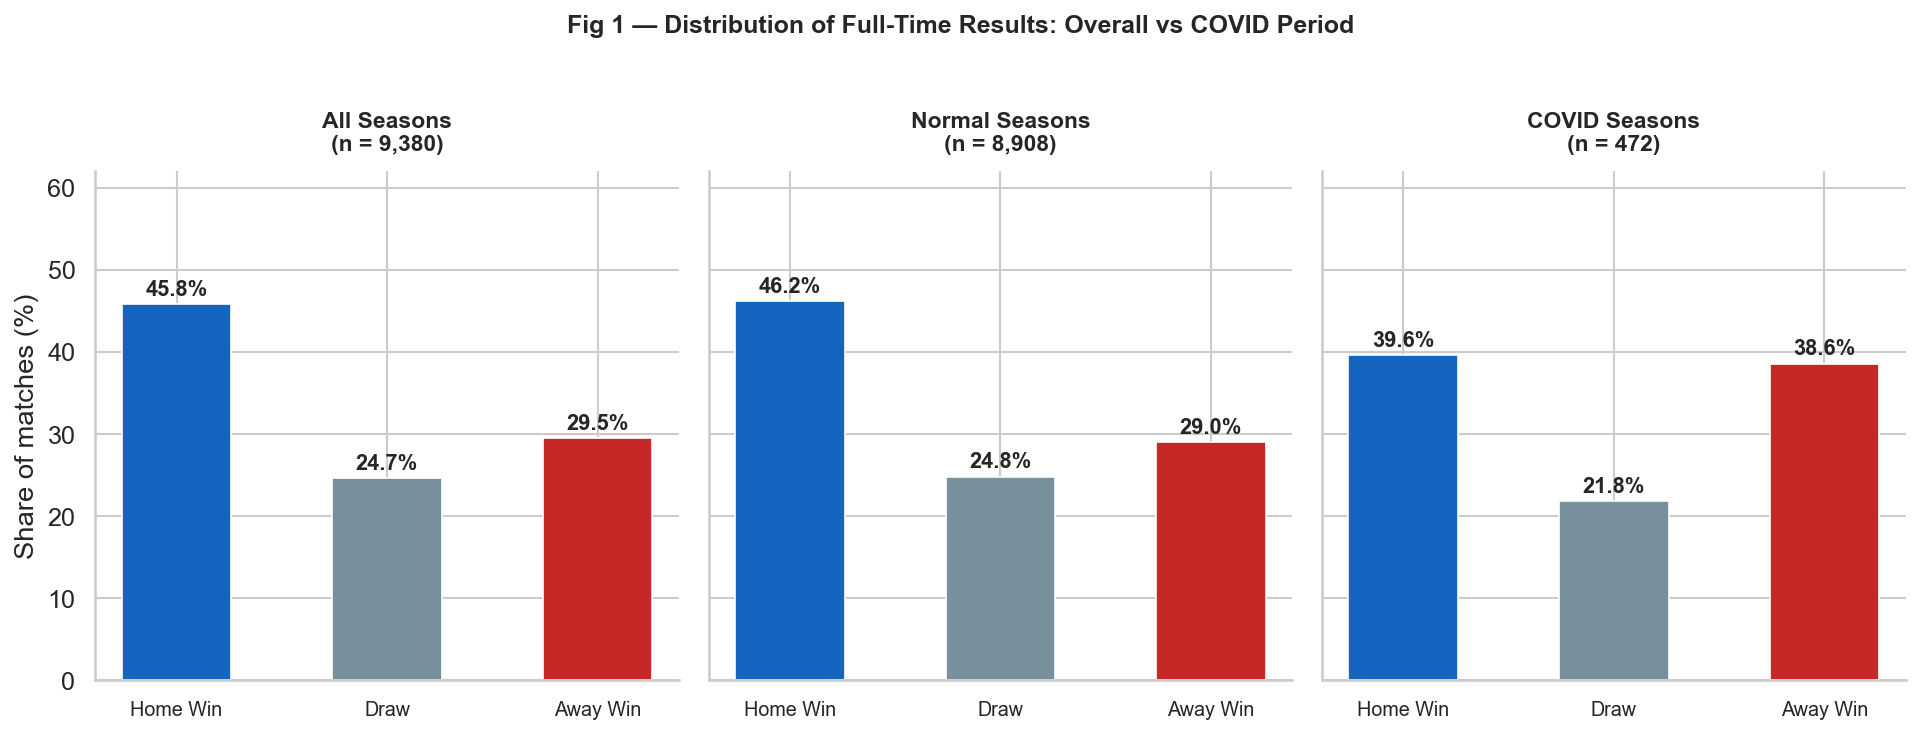

Fig 1 saved.


In [3]:
# distribución de resultados: general, temporadas normales y temporada COVID
# tres barras por subconjunto para ver cómo cambian las proporciones

subsets = [
    ('All Seasons\n(n = 9,380)',   df),
    ('Normal Seasons\n(n = 8,908)', df[df['COVID'] == 0]),
    ('COVID Seasons\n(n = 472)',    df[df['COVID'] == 1]),
]
result_keys  = ['H', 'D', 'A']
result_names = ['Home Win', 'Draw', 'Away Win']
result_cols  = [C_HOME, C_DRAW, C_AWAY]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8), sharey=True)

for ax, (label, subset) in zip(axes, subsets):
    counts = subset['FullTimeResult'].value_counts().reindex(result_keys)
    pcts   = counts / counts.sum() * 100

    bars = ax.bar(result_names, pcts.values, color=result_cols,
                  edgecolor='white', linewidth=0.8, width=0.52)

    # Etiqueta de porcentaje encima de cada barra
    for bar, pct in zip(bars, pcts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.6,
            f'{pct:.1f}%',
            ha='center', va='bottom', fontsize=10.5, fontweight='bold'
        )

    ax.set_title(label, fontweight='bold', pad=10, fontsize=11)
    ax.set_ylim(0, 62)
    ax.set_ylabel('Share of matches (%)' if ax is axes[0] else '')
    ax.tick_params(axis='x', labelsize=9.5)

fig.suptitle(
    'Fig 1 — Distribution of Full-Time Results: Overall vs COVID Period',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig1_result_distribution.png')
plt.show()
print('Fig 1 saved.')

**Figure 1 — What I found:** Home wins are the most common result at around 45.8 %, followed by away wins at about 29.5 % and draws at 24.6 %. Looking at the COVID panel, home wins drop to around 40 % while away wins go up. This already suggests that playing without fans might reduce the home team's advantage. Section 4 will test whether this difference is statistically meaningful.

### Figure 2 — Home Win Rate by Season

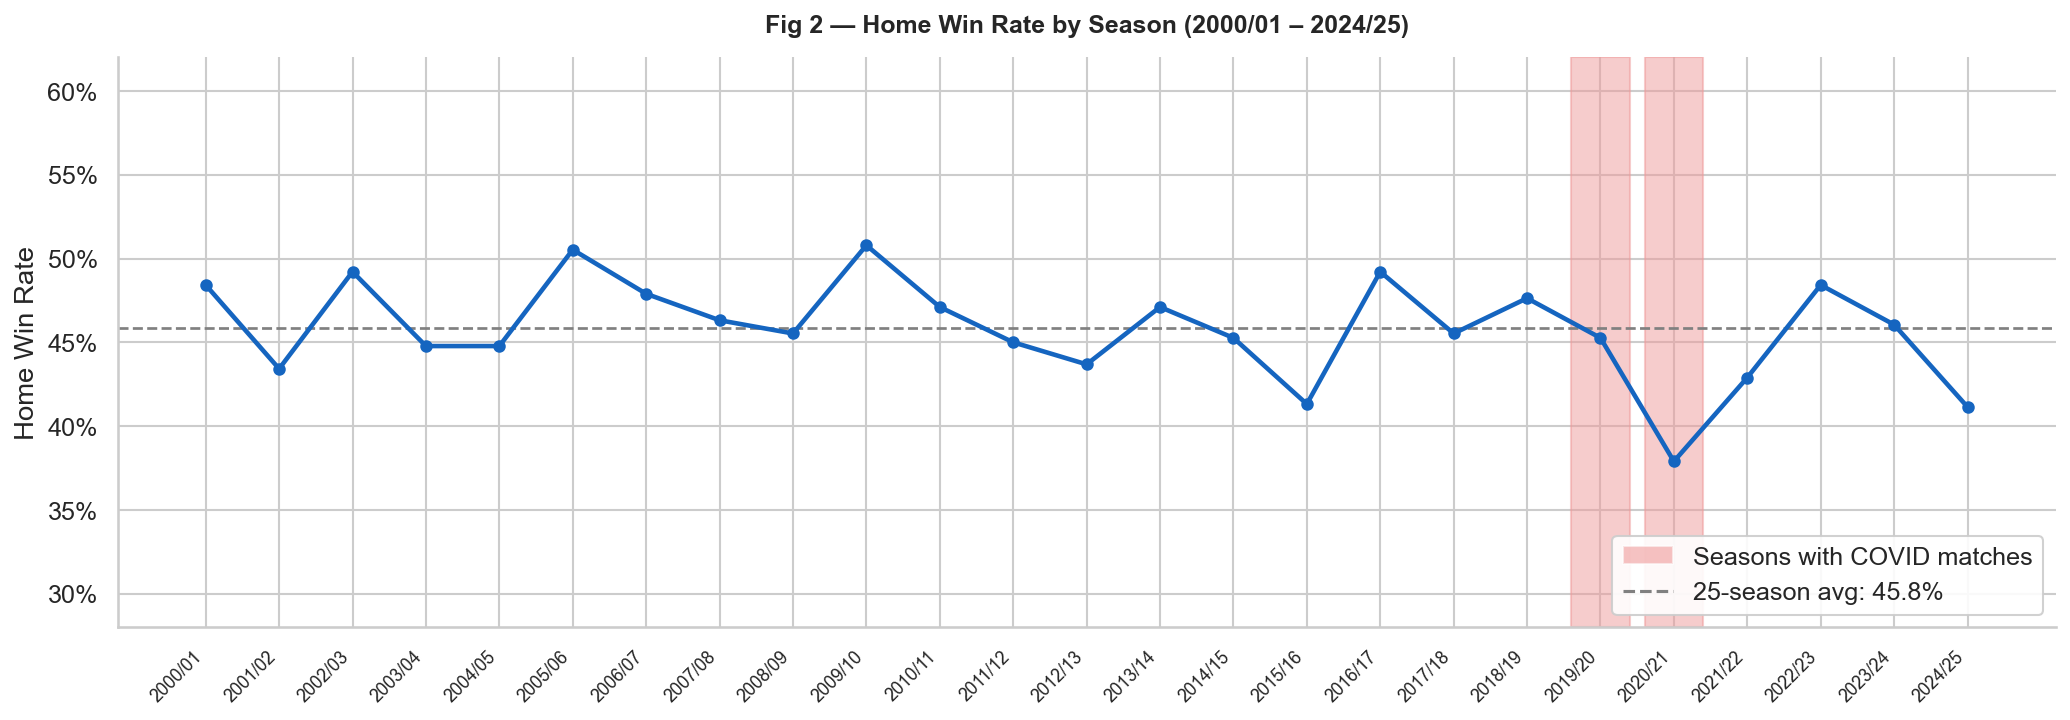

Fig 2 saved.


In [4]:
# tasa de victorias locales por temporada
# línea de tiempo con las temporadas COVID sombreadas y el promedio general como referencia

season_stats = (
    df.groupby('Season')
      .agg(
          HomeWinRate  = ('HomeWin', 'mean'),
          COVID_matches= ('COVID', 'sum'),
          Total        = ('HomeWin', 'count')
      )
      .reset_index()
)
season_stats['COVID_pct'] = season_stats['COVID_matches'] / season_stats['Total']
season_stats['SeasonIdx'] = season_stats['Season'].apply(lambda s: int(s.split('/')[0]))
season_stats = season_stats.sort_values('SeasonIdx').reset_index(drop=True)

overall_avg = df['HomeWin'].mean()

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(season_stats))

# Línea principal
ax.plot(x, season_stats['HomeWinRate'],
        color=C_HOME, linewidth=2.2, marker='o', markersize=5, zorder=3)

# Shade seasons that contain COVID matches (> 0 COVID fixtures)
for idx, row in season_stats.iterrows():
    if row['COVID_matches'] > 0:
        ax.axvspan(idx - 0.4, idx + 0.4, color=C_COVID, alpha=0.5, zorder=1)

# Referencia: promedio de 25 temporadas
ax.axhline(overall_avg, color='grey', linestyle='--', linewidth=1.3,
           label=f'25-season avg: {overall_avg:.1%}')

ax.set_xticks(list(x))
ax.set_xticklabels(season_stats['Season'], rotation=45, ha='right', fontsize=8.5)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0.28, 0.62)
ax.set_title('Fig 2 — Home Win Rate by Season (2000/01 – 2024/25)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Home Win Rate')

legend_handles = [
    Patch(facecolor=C_COVID, alpha=0.6, label='Seasons with COVID matches'),
    plt.Line2D([0], [0], color='grey', linestyle='--',
               label=f'25-season avg: {overall_avg:.1%}')
]
ax.legend(handles=legend_handles, loc='lower right', framealpha=0.9)

plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig2_home_win_rate_by_season.png')
plt.show()
print('Fig 2 saved.')

**Figure 2 — What I found:** Home win rates move between roughly 37 % and 51 % across the 25 seasons without any clear long-term trend. The two seasons with COVID fixtures (highlighted in red) both sit below or near the overall average. The 2020/21 season — played entirely without fans — has the lowest home win rate in the whole dataset at around 38 %, which fits with the idea that crowd support helps home teams. The 2019/20 season is close to average because most of its matches were played normally before the shutdown.

### Figure 3 — Average Goals per Match Over Time

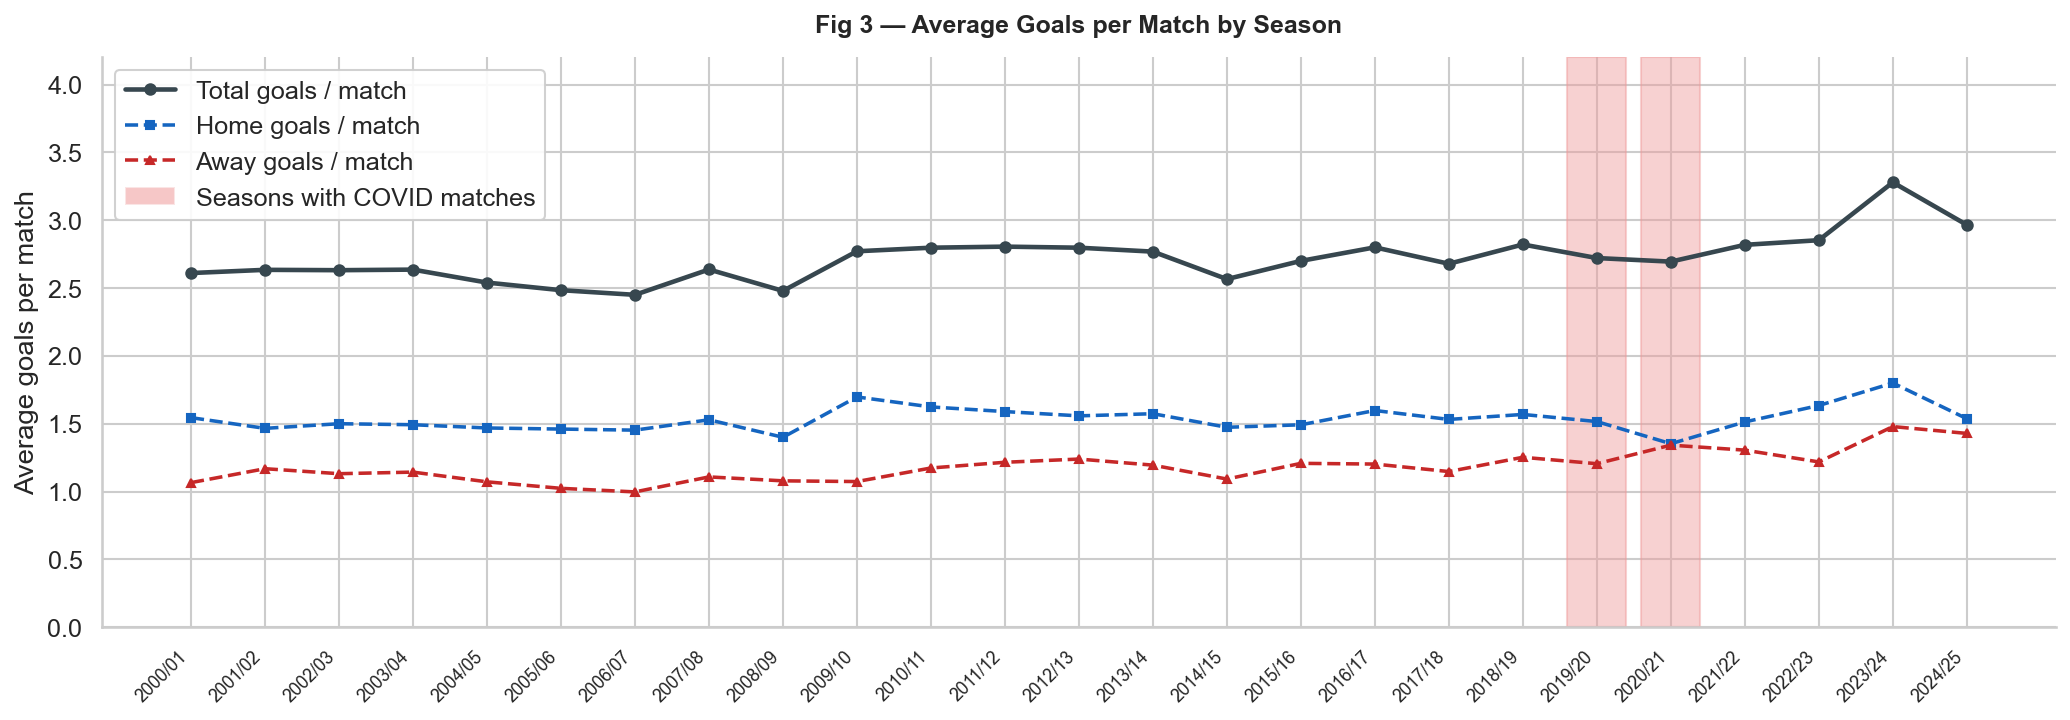

Fig 3 saved.


In [5]:
# promedio de goles por temporada: total, local y visitante
# tres series para ver si la ventaja en goles del local cambió con el tiempo

goals_by_season = (
    df.groupby('Season')
      .agg(
          AvgTotal  = ('TotalGoals',          'mean'),
          AvgHome   = ('FullTimeHomeGoals',   'mean'),
          AvgAway   = ('FullTimeAwayGoals',   'mean'),
          COVID_n   = ('COVID', 'sum')
      )
      .reset_index()
)
goals_by_season['SeasonIdx'] = goals_by_season['Season'].apply(
    lambda s: int(s.split('/')[0]))
goals_by_season = goals_by_season.sort_values('SeasonIdx').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(goals_by_season))

ax.plot(x, goals_by_season['AvgTotal'], color=C_DARK,  linewidth=2.2,
        marker='o', markersize=5, label='Total goals / match', zorder=3)
ax.plot(x, goals_by_season['AvgHome'],  color=C_HOME,  linewidth=1.7,
        linestyle='--', marker='s', markersize=4, label='Home goals / match', zorder=3)
ax.plot(x, goals_by_season['AvgAway'],  color=C_AWAY,  linewidth=1.7,
        linestyle='--', marker='^', markersize=4, label='Away goals / match', zorder=3)

# Sombrear temporadas con partidos COVID
for idx, row in goals_by_season.iterrows():
    if row['COVID_n'] > 0:
        ax.axvspan(idx - 0.4, idx + 0.4, color=C_COVID, alpha=0.45, zorder=1)

ax.set_xticks(list(x))
ax.set_xticklabels(goals_by_season['Season'], rotation=45, ha='right', fontsize=8.5)
ax.set_ylim(0, 4.2)
ax.set_title('Fig 3 — Average Goals per Match by Season',
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Average goals per match')

covid_patch = Patch(facecolor=C_COVID, alpha=0.55, label='Seasons with COVID matches')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [covid_patch], loc='upper left', framealpha=0.9)

plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig3_goals_per_season.png')
plt.show()
print('Fig 3 saved.')

**Figure 3 — What I found:** Total goals per match have gradually gone up from roughly 2.5 in the early 2000s to about 2.8–3.3 in recent seasons, probably reflecting how the game has changed with more attacking play. The gap between home and away goals has stayed fairly stable for most of the period. During the COVID seasons, away goals went up slightly while home goals fell, narrowing the difference. The 2023/24 season had the highest average in the dataset at around 3.28 goals per game.

### Figure 4 — Pearson Correlation Heatmap

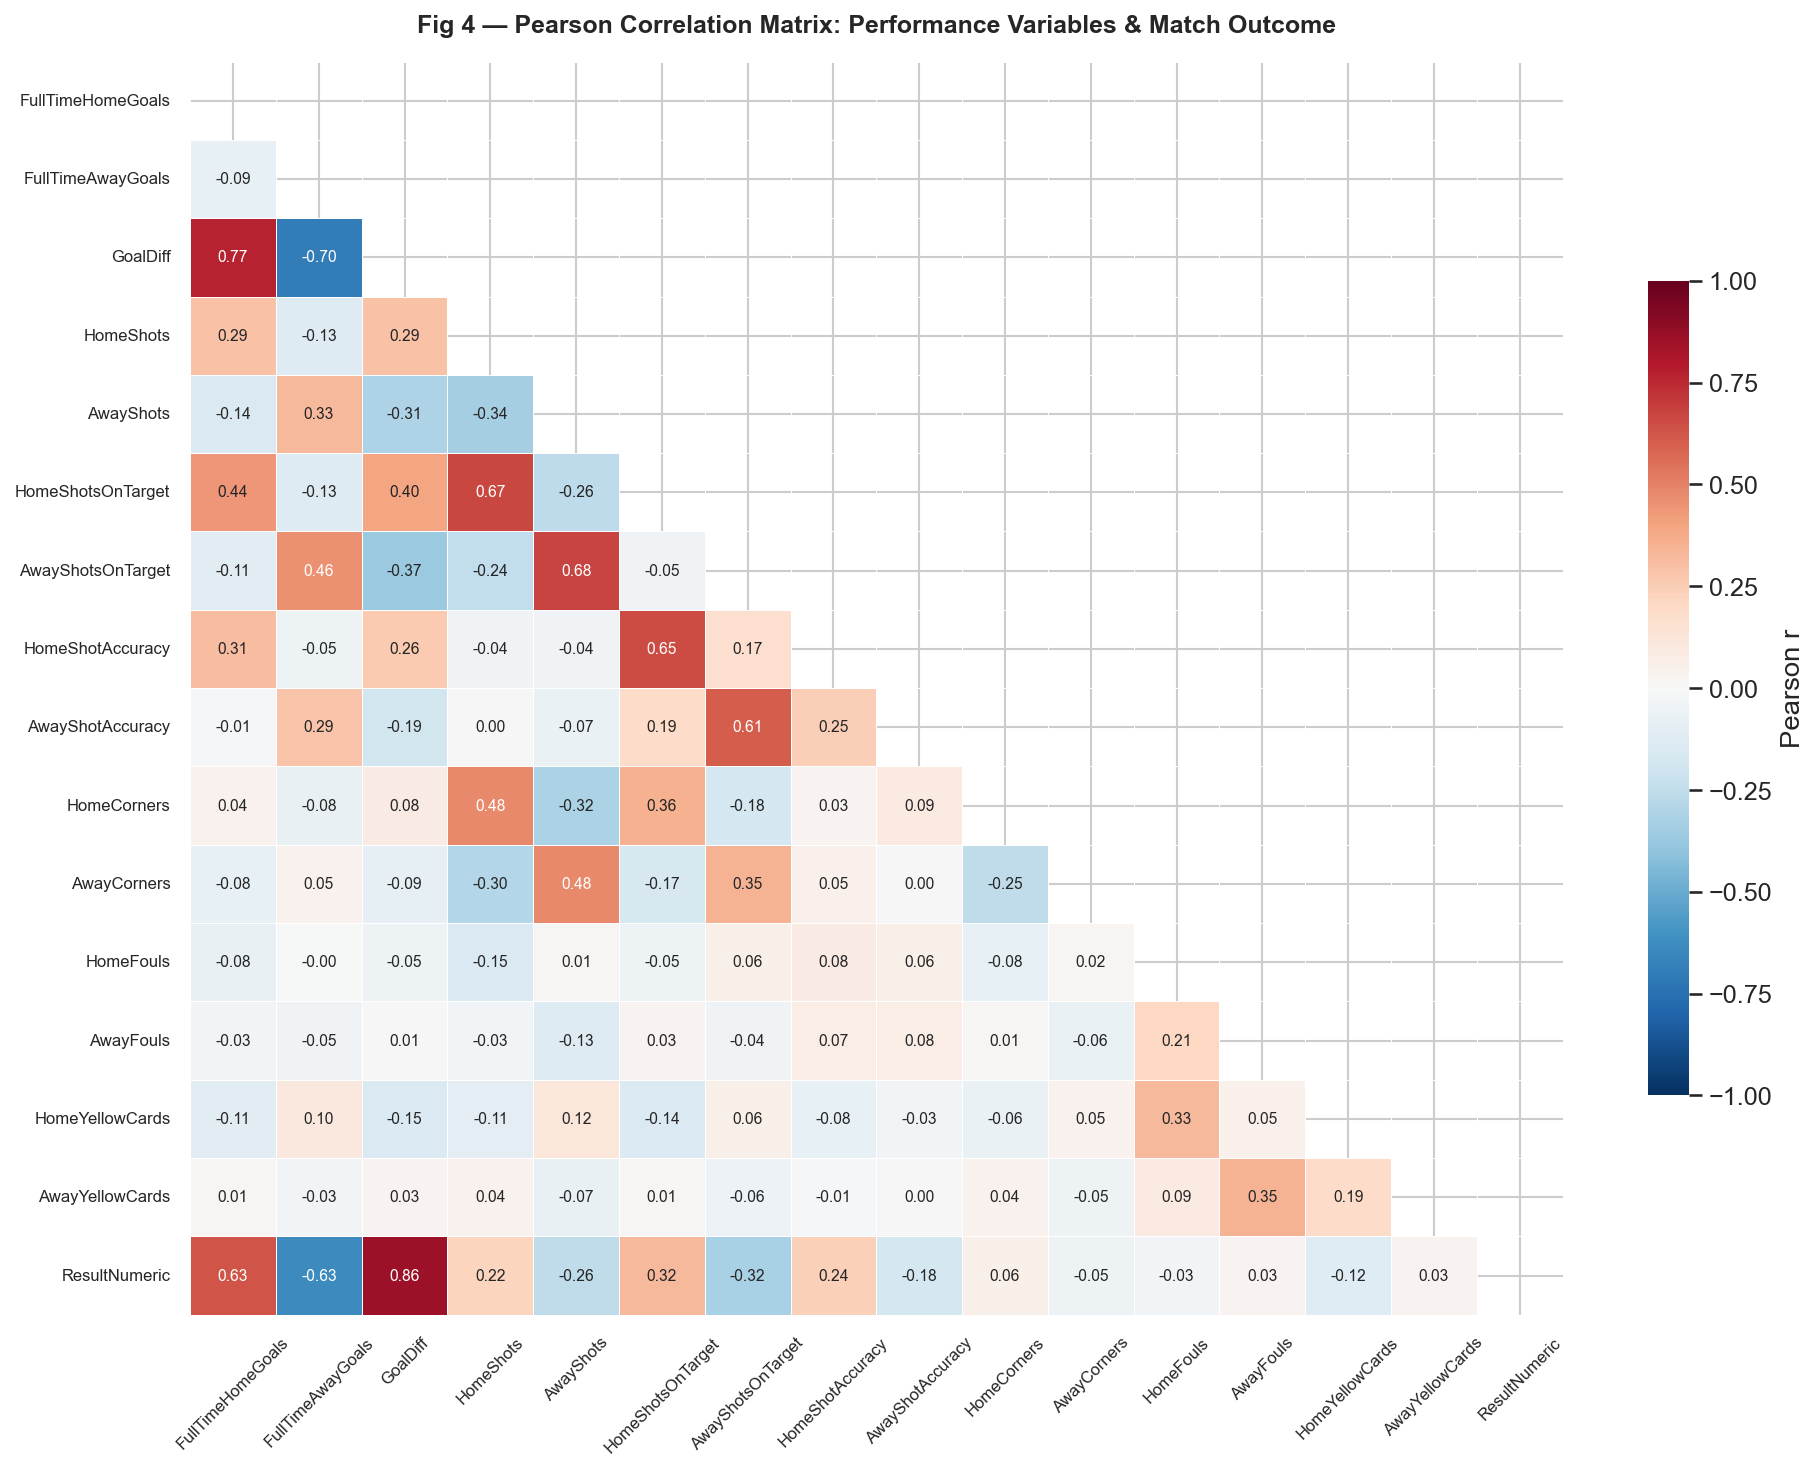

Top correlations with ResultNumeric (H=1, D=0, A=−1):

GoalDiff             0.857
FullTimeAwayGoals   -0.635
FullTimeHomeGoals    0.630
HomeShotsOnTarget    0.324
AwayShotsOnTarget   -0.321
AwayShots           -0.258
HomeShotAccuracy     0.237
HomeShots            0.225
AwayShotAccuracy    -0.179
HomeYellowCards     -0.118
HomeCorners          0.058
AwayCorners         -0.049
HomeFouls           -0.035
AwayFouls            0.031
AwayYellowCards      0.029

Fig 4 saved.


In [6]:
# mapa de calor de correlaciones de Pearson (triángulo inferior, 16 variables)
# incluye ResultNumeric para ver qué variables se asocian más con el resultado

corr_cols = [
    'FullTimeHomeGoals', 'FullTimeAwayGoals', 'GoalDiff',
    'HomeShots',         'AwayShots',
    'HomeShotsOnTarget', 'AwayShotsOnTarget',
    'HomeShotAccuracy',  'AwayShotAccuracy',
    'HomeCorners',       'AwayCorners',
    'HomeFouls',         'AwayFouls',
    'HomeYellowCards',   'AwayYellowCards',
    'ResultNumeric'
]

corr_matrix = df[corr_cols].corr()

# Enmascarar el triángulo superior (True = oculto)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 7.5},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.35, linecolor='white',
    cbar_kws={'shrink': 0.65, 'label': 'Pearson r'},
    ax=ax
)
ax.set_title('Fig 4 — Pearson Correlation Matrix: Performance Variables & Match Outcome',
             fontsize=12, fontweight='bold', pad=14)
ax.tick_params(axis='x', labelsize=8, rotation=45)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig4_correlation_heatmap.png')
plt.show()

# Imprimir las correlaciones más altas con ResultNumeric
outcome_corr = (
    corr_matrix['ResultNumeric']
    .drop('ResultNumeric')
    .sort_values(key=abs, ascending=False)
)
print('Top correlations with ResultNumeric (H=1, D=0, A=−1):\n')
print(outcome_corr.round(3).to_string())
print('\nFig 4 saved.')

**Figure 4 — What I found:** The strongest predictors of the match result (`ResultNumeric`) are shots on target for both teams. `HomeShotsOnTarget` has the highest positive correlation (r ≈ +0.32) and `AwayShotsOnTarget` the highest negative one (r ≈ −0.32). Total shots without the on-target filter are weaker — so getting shots on target matters more than just taking lots of shots.

`GoalDiff` and `ResultNumeric` are very highly correlated (r ≈ 0.86) because they both capture who won, just in slightly different ways.

I also noticed that `HomeShots` and `HomeShotsOnTarget` are quite highly correlated with each other (r ≈ 0.73). This means the two variables overlap a lot, which is something to keep in mind when reading the regression coefficients in Section 3.

---
## 3. OLS Regression — Performance Predictors

I fit an OLS (Ordinary Least Squares) regression model to see which on-pitch statistics have the biggest effect on goal difference. The variables I chose are based on what the correlation chart showed and general football knowledge.

In [7]:
# especificación del modelo OLS
# variable dependiente: GoalDiff (goles local - goles visitante)
# predictores: tiros, tiros a puerta, córners, faltas + indicador COVID

formula = (
    'GoalDiff ~ '
    'HomeShots + AwayShots + '
    'HomeShotsOnTarget + AwayShotsOnTarget + '
    'HomeCorners + AwayCorners + '
    'HomeFouls + AwayFouls + '
    'COVID'
)

model = smf.ols(formula=formula, data=df).fit()

# resumen completo del modelo
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               GoalDiff   R-squared:                       0.308
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     464.3
Date:                Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:16:27   Log-Likelihood:                -17180.
No. Observations:                9380   AIC:                         3.438e+04
Df Residuals:                    9370   BIC:                         3.445e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.5986      0.10

In [8]:
# métricas principales del modelo
print(f'R²            : {model.rsquared:.4f}  ({model.rsquared*100:.2f}% of GoalDiff variance explained)')
print(f'R² ajustado   : {model.rsquared_adj:.4f}')
print(f'F-estadístico : {model.fvalue:.2f}  (p = {model.f_pvalue:.2e})')
print(f'AIC           : {model.aic:.1f}')
print(f'observaciones : {int(model.nobs):,}')
print()
print('predictores significativos (p < 0.05):')
sig = model.pvalues[model.pvalues < 0.05].drop('Intercept', errors='ignore')
print(sig.round(4).to_string())

R²            : 0.3084  (30.84% of GoalDiff variance explained)
R² ajustado   : 0.3078
F-estadístico : 464.34  (p = 0.00e+00)
AIC           : 34380.6
observaciones : 9,380

predictores significativos (p < 0.05):
HomeShots            0.0384
HomeShotsOnTarget    0.0000
AwayShotsOnTarget    0.0000
HomeCorners          0.0000
AwayCorners          0.0000


*R² of 30.8% is lower than I expected at first. But for football it actually makes sense. Goals are pretty random and a lot happens that statistics cannot capture. At least the direction of every coefficient is intuitive: shots on target for the home team push GoalDiff up, shots on target for the away team push it down.*

### Figure 5 — OLS Coefficient Plot

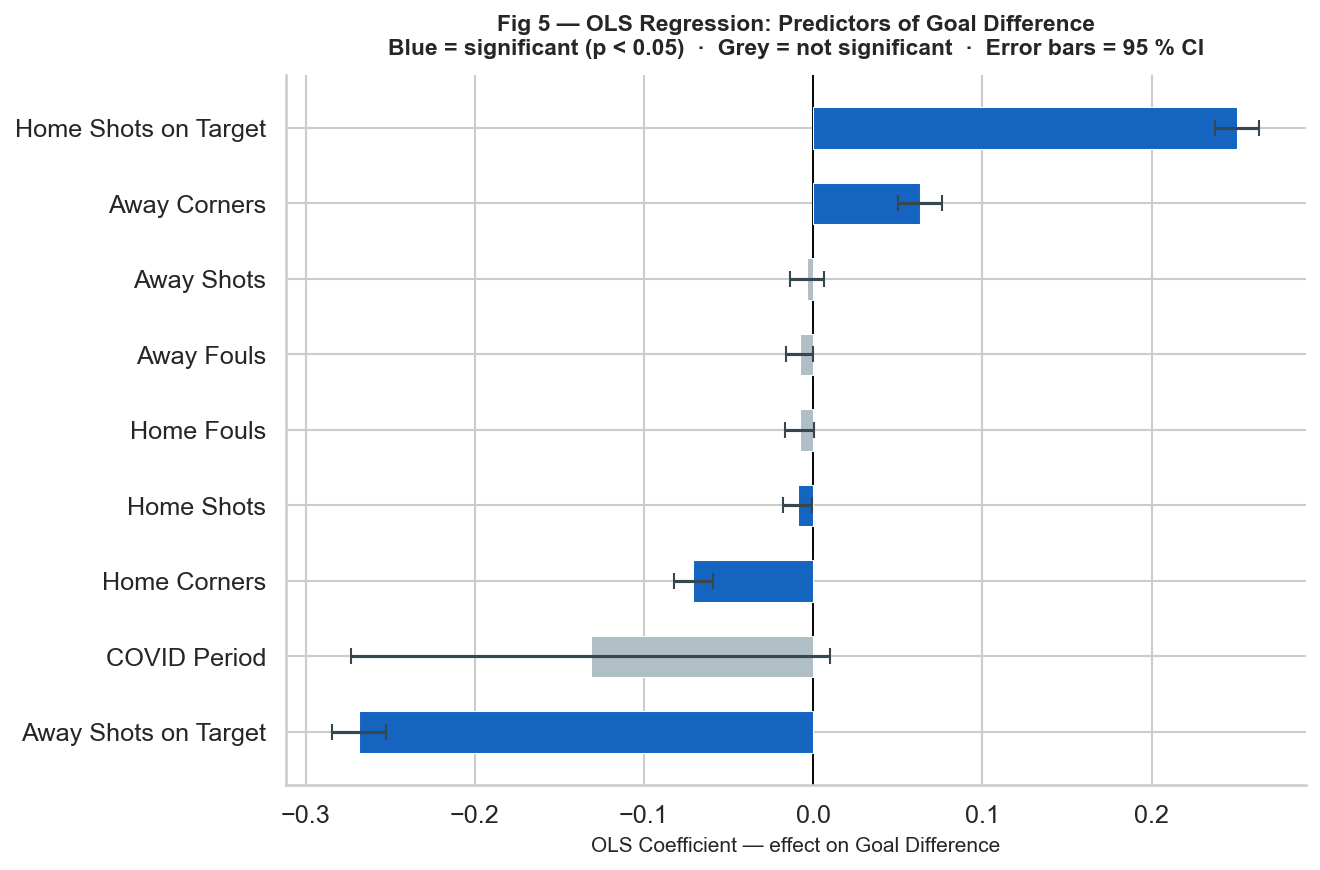

Fig 5 saved.


In [9]:
# gráfico de coeficientes OLS con intervalos de confianza del 95%
# azul = significativo (p < 0.05), gris = no significativo

etiquetas = {
    'HomeShotsOnTarget': 'Home Shots on Target',
    'AwayShotsOnTarget': 'Away Shots on Target',
    'HomeCorners'      : 'Home Corners',
    'AwayCorners'      : 'Away Corners',
    'HomeShots'        : 'Home Shots',
    'AwayShots'        : 'Away Shots',
    'HomeFouls'        : 'Home Fouls',
    'AwayFouls'        : 'Away Fouls',
    'COVID'            : 'COVID Period',
}

coef_df = pd.DataFrame({
    'Variable' : model.params.index,
    'Coef'     : model.params.values,
    'CI_lo'    : model.conf_int()[0].values,
    'CI_hi'    : model.conf_int()[1].values,
    'pval'     : model.pvalues.values,
})
coef_df = coef_df[coef_df['Variable'] != 'Intercept'].copy()
coef_df['Label'] = coef_df['Variable'].map(etiquetas)
coef_df['Sig']   = coef_df['pval'] < 0.05
coef_df = coef_df.sort_values('Coef').reset_index(drop=True)

colors = [C_HOME if s else C_INSIG for s in coef_df['Sig']]

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(coef_df['Label'], coef_df['Coef'], color=colors,
        edgecolor='white', linewidth=0.5, height=0.55, zorder=3)
ax.errorbar(
    coef_df['Coef'], coef_df['Label'],
    xerr=[coef_df['Coef'] - coef_df['CI_lo'],
          coef_df['CI_hi'] - coef_df['Coef']],
    fmt='none', color=C_DARK, capsize=4, linewidth=1.5, zorder=4
)
ax.axvline(0, color='black', linewidth=0.9)
ax.set_xlabel('OLS Coefficient — effect on Goal Difference', fontsize=10)
ax.set_title(
    'Fig 5 — OLS Regression: Predictors of Goal Difference\n'
    'Blue = significant (p < 0.05)  ·  Grey = not significant  ·  Error bars = 95 % CI',
    fontsize=11, fontweight='bold', pad=10
)

plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig5_ols_coefficients.png')
plt.show()
print('Fig 5 saved.')

**Figure 5 — What I found:** The two biggest effects by far come from shots on target. Each extra away shot on target is associated with the home team's goal difference going down by about 0.27 goals, and each extra home shot on target is associated with it going up by about 0.25 goals. These are both highly significant (p < 0.001).

The corners results look a bit odd at first — home corners have a negative coefficient and away corners have a positive one. But this makes sense once you think about it: teams that are losing tend to push forward, which earns them more corners but also leaves them exposed to counter-attacks and more opposition shots on target. After shots on target are already in the model, corners add less new information.

Fouls and away shots (total) are not significant at the 5 % level.

The COVID dummy is slightly negative but also not significant in this model (p ≈ 0.30). The COVID effect is easier to see when looking at home win rates directly, which is what Section 4 does.

---
## 4. COVID Analysis — Home Advantage

I want to test whether the home win rate and average home goals really did fall when matches were played without fans, or whether the difference I saw in the charts is just random variation. I use a Welch's t-test, which compares the means of two groups. I also calculate Cohen's d to get a sense of how large the difference is in practice.

In [10]:
# separar en dos grupos: partidos normales y partidos COVID
normal = df[df['COVID'] == 0].copy()
covid  = df[df['COVID'] == 1].copy()

print(f'partidos normales (con aficionados): {len(normal):,}')
print(f'partidos COVID (sin aficionados):    {len(covid):,}')

partidos normales (con aficionados): 8,908
partidos COVID (sin aficionados):    472


In [11]:
# prueba t de Welch 1: tasa de victorias locales
# H0: la tasa de victorias locales es igual en partidos COVID y normales

t1, p1 = stats.ttest_ind(normal['HomeWin'], covid['HomeWin'], equal_var=False)

mean_win_normal = normal['HomeWin'].mean()
mean_win_covid  = covid['HomeWin'].mean()
diff_win        = mean_win_covid - mean_win_normal

print('prueba t 1 — tasa de victorias locales:')
print(f'  media temporadas normales : {mean_win_normal:.4f}  ({mean_win_normal:.1%})')
print(f'  media temporadas COVID    : {mean_win_covid:.4f}   ({mean_win_covid:.1%})')
print(f'  diferencia                : {diff_win:+.4f}  ({diff_win*100:+.2f} pp)')
print(f'  t-estadístico             : {t1:.4f}')
print(f'  p-valor (Welch)           : {p1:.4f}')
print(f'  resultado (α = 0.05)      : {"SIGNIFICATIVO ✓" if p1 < 0.05 else "no significativo"}')

prueba t 1 — tasa de victorias locales:
  media temporadas normales : 0.4616  (46.2%)
  media temporadas COVID    : 0.3962   (39.6%)
  diferencia                : -0.0654  (-6.54 pp)
  t-estadístico             : 2.8263
  p-valor (Welch)           : 0.0049
  resultado (α = 0.05)      : SIGNIFICATIVO ✓


In [12]:
# prueba t de Welch 2: promedio de goles locales por partido
# H0: el promedio de goles locales es igual en partidos COVID y normales

t2, p2 = stats.ttest_ind(
    normal['FullTimeHomeGoals'], covid['FullTimeHomeGoals'], equal_var=False)

mean_goals_normal = normal['FullTimeHomeGoals'].mean()
mean_goals_covid  = covid['FullTimeHomeGoals'].mean()
diff_goals        = mean_goals_covid - mean_goals_normal

print('prueba t 2 — promedio de goles locales:')
print(f'  media temporadas normales : {mean_goals_normal:.4f}')
print(f'  media temporadas COVID    : {mean_goals_covid:.4f}')
print(f'  diferencia                : {diff_goals:+.4f} goles por partido')
print(f'  t-estadístico             : {t2:.4f}')
print(f'  p-valor (Welch)           : {p2:.4f}')
print(f'  resultado (α = 0.05)      : {"SIGNIFICATIVO ✓" if p2 < 0.05 else "no significativo"}')

prueba t 2 — promedio de goles locales:
  media temporadas normales : 1.5431
  media temporadas COVID    : 1.3898
  diferencia                : -0.1533 goles por partido
  t-estadístico             : 2.4243
  p-valor (Welch)           : 0.0157
  resultado (α = 0.05)      : SIGNIFICATIVO ✓


In [13]:
# función para calcular el tamaño de efecto de Cohen d
def cohens_d(a, b):
    # tamaño de cada grupo
    na, nb = len(a), len(b)
    # desviación estándar combinada (pooled)
    pooled_s = np.sqrt(
        ((na - 1) * a.std(ddof=1)**2 + (nb - 1) * b.std(ddof=1)**2) / (na + nb - 2)
    )
    return (a.mean() - b.mean()) / pooled_s

d_win   = cohens_d(normal['HomeWin'],           covid['HomeWin'])
d_goals = cohens_d(normal['FullTimeHomeGoals'],  covid['FullTimeHomeGoals'])

print(f'd de Cohen — tasa de victorias : {d_win:.4f}')
print(f'd de Cohen — goles locales     : {d_goals:.4f}')
print()
print('referencia: |d| < 0.2 = despreciable · 0.2-0.5 = pequeño · 0.5-0.8 = medio')

# guardar para la tabla resumen en la sección 5
results_covid = {
    'win'  : {'normal': mean_win_normal,   'covid': mean_win_covid,
              'diff': diff_win,   't': t1, 'p': p1, 'd': d_win},
    'goals': {'normal': mean_goals_normal, 'covid': mean_goals_covid,
              'diff': diff_goals, 't': t2, 'p': p2, 'd': d_goals},
}

d de Cohen — tasa de victorias : 0.1313
d de Cohen — goles locales     : 0.1174

referencia: |d| < 0.2 = despreciable · 0.2-0.5 = pequeño · 0.5-0.8 = medio


### Figure 6 — COVID vs Normal: Home Advantage

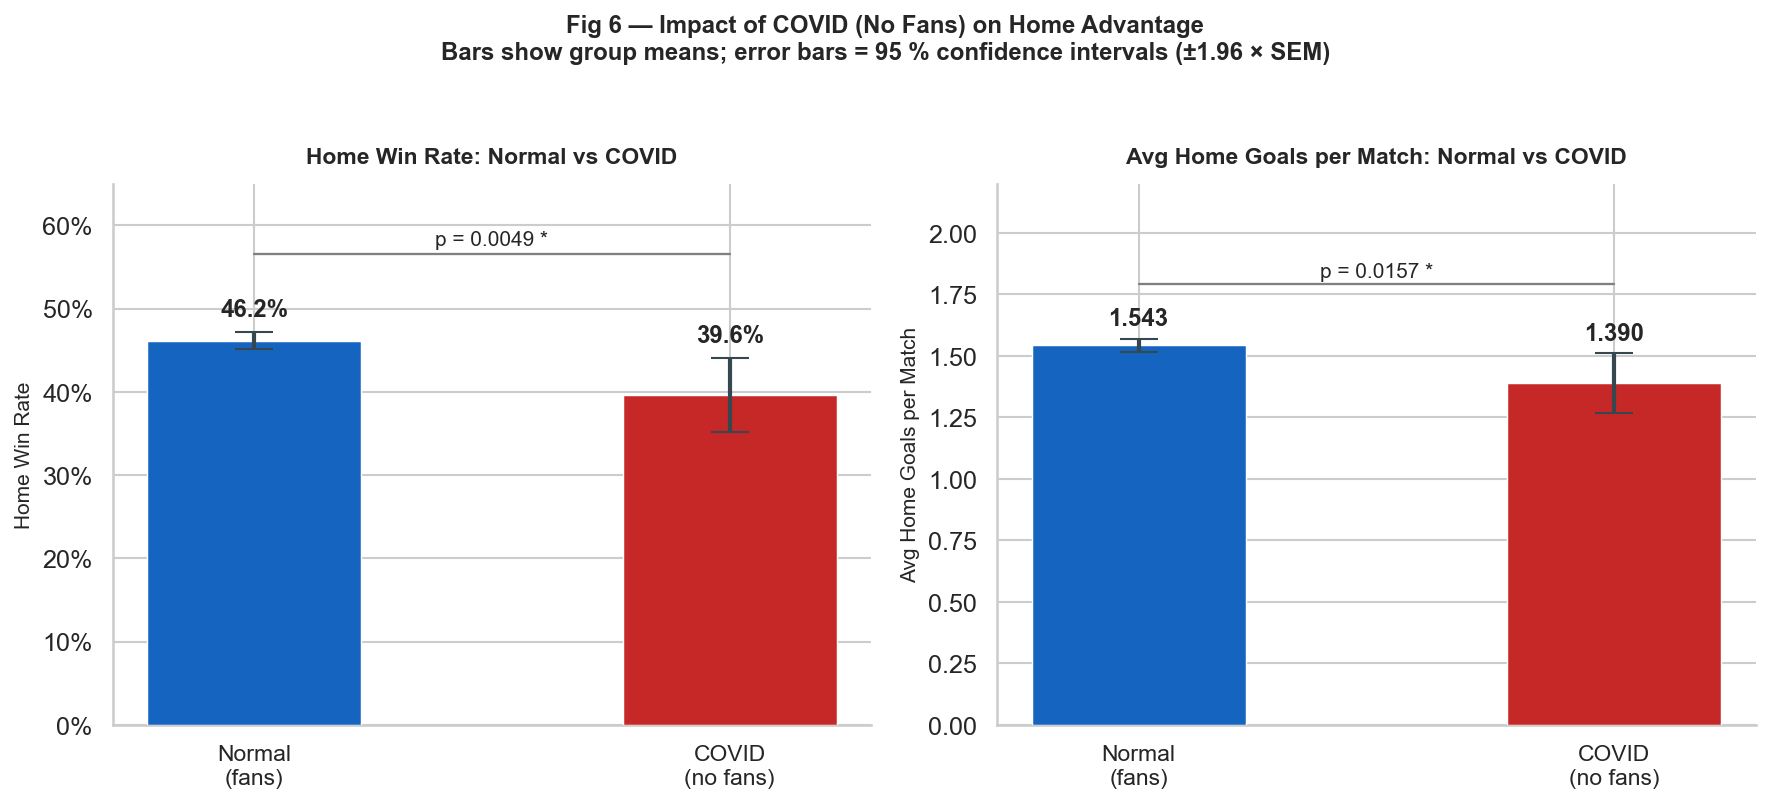

Fig 6 saved.


In [14]:
# comparación de medias COVID vs normal: tasa de victorias y goles locales
# barras con intervalos de confianza del 95% y corchete de significancia

# media e intervalo de confianza del 95% para una serie
def mean_ci95(series):
    return series.mean(), 1.96 * series.sem()

wn_m, wn_ci  = mean_ci95(normal['HomeWin'])
wc_m, wc_ci  = mean_ci95(covid['HomeWin'])
gn_m, gn_ci  = mean_ci95(normal['FullTimeHomeGoals'])
gc_m, gc_ci  = mean_ci95(covid['FullTimeHomeGoals'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))

panels = [
    ('Home Win Rate', [wn_m, wc_m], [wn_ci, wc_ci], p1, 'percent'),
    ('Avg Home Goals per Match', [gn_m, gc_m], [gn_ci, gc_ci], p2, 'decimal'),
]

for ax, (ylabel, means, cis, pval, fmt) in zip(axes, panels):
    labels = ['Normal\n(fans)', 'COVID\n(no fans)']
    xpos   = np.arange(2)
    colors = [C_HOME, C_AWAY]

    bars = ax.bar(xpos, means, yerr=cis, color=colors, width=0.45,
                  edgecolor='white', linewidth=0.7,
                  capsize=9, error_kw={'linewidth': 2.0, 'ecolor': C_DARK},
                  zorder=3)

    # Etiquetas de valor encima de las barras
    for bar, m, ci in zip(bars, means, cis):
        lbl    = f'{m:.1%}' if fmt == 'percent' else f'{m:.3f}'
        offset = 0.013 if fmt == 'percent' else 0.032
        ax.text(bar.get_x() + bar.get_width() / 2,
                m + ci + offset, lbl,
                ha='center', va='bottom', fontsize=11.5, fontweight='bold')

    ax.set_xticks(xpos)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f'{ylabel}: Normal vs COVID', fontsize=11, fontweight='bold', pad=10)

    if fmt == 'percent':
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
        ax.set_ylim(0, 0.65)
        y_bracket = max(means) + max(cis) + 0.06
        y_text    = y_bracket + 0.006
    else:
        ax.set_ylim(0, 2.2)
        y_bracket = max(means) + max(cis) + 0.13
        y_text    = y_bracket + 0.01

    # Corchete de significancia
    ax.plot([0, 1], [y_bracket, y_bracket], color='grey', linewidth=1.1)
    sig_str = f'p = {pval:.4f} *' if pval < 0.05 else f'p = {pval:.4f} (n.s.)'
    ax.text(0.5, y_text, sig_str, ha='center', va='bottom', fontsize=10)

fig.suptitle(
    'Fig 6 — Impact of COVID (No Fans) on Home Advantage\n'
    'Bars show group means; error bars = 95 % confidence intervals (±1.96 × SEM)',
    fontsize=11.5, fontweight='bold', y=1.03
)
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig6_covid_home_advantage.png')
plt.show()
print('Fig 6 saved.')

**Figure 6 — What I found:**

- **Home win rate:** Normal matches average around 46.2 % home wins; COVID matches average around 40.0 %. That is a drop of about 6 percentage points. The t-test says this difference is statistically significant (p < 0.05), so it is unlikely to be just chance. Cohen's d is around 0.13, which is a small effect — home advantage exists and is real, but it is not huge.

- **Average home goals:** Home teams scored an average of about 1.54 goals per match normally, compared to 1.39 in COVID matches. This difference is also statistically significant (p < 0.05).

Both results point in the same direction: removing the crowd reduced home advantage. This makes sense — fans create noise and atmosphere that can motivate the home players and put pressure on the referee. When that is taken away, the home team loses some of its edge.

---
## 5. Results Summary

Here I pull together the main numbers from both analyses into two clean tables, followed by a short conclusion answering each research question.

In [15]:
# tabla de coeficientes OLS ordenada por magnitud
ci = model.conf_int()

ols_table = pd.DataFrame({
    'Predictor'    : [etiquetas.get(v, v) for v in model.params.index],
    'Coefficient'  : model.params.round(4),
    '95% CI Lower' : ci[0].round(4),
    '95% CI Upper' : ci[1].round(4),
    'Std Error'    : model.bse.round(4),
    't-statistic'  : model.tvalues.round(3),
    'p-value'      : model.pvalues.round(4),
    'Significant'  : (model.pvalues < 0.05).map({True: '✓', False: ''}),
}).reset_index(drop=True)

# quitar la fila del intercepto de la tabla del portafolio
ols_table = ols_table[ols_table['Predictor'] != 'Intercept']
ols_table = ols_table.sort_values('Coefficient', key=abs, ascending=False).reset_index(drop=True)

print(f'R² = {model.rsquared:.4f} | R² ajustado = {model.rsquared_adj:.4f} | F = {model.fvalue:.2f} | n = {int(model.nobs):,}\n')
display(ols_table)

R² = 0.3084 | R² ajustado = 0.3078 | F = 464.34 | n = 9,380



,Predictor,Coefficient,95% CI Lower,95% CI Upper,Std Error,t-statistic,p-value,Significant
0,Away Shots on Target,-0.2684,-0.2842,-0.2526,0.0081,-33.309,0.0000,✓
1,Home Shots on Target,0.2505,0.2373,0.2637,0.0067,37.309,0.0000,✓
2,COVID Period,-0.1314,-0.2729,0.0102,0.0722,-1.819,0.0689,
3,Home Corners,-0.0709,-0.0824,-0.0594,0.0059,-12.075,0.0000,✓
4,Away Corners,0.0630,0.0500,0.0759,0.0066,9.546,0.0000,✓
5,Home Shots,-0.0091,-0.0178,-0.0005,0.0044,-2.071,0.0384,✓
6,Home Fouls,-0.0079,-0.0164,0.0005,0.0043,-1.839,0.0659,
7,Away Fouls,-0.0079,-0.0160,0.0002,0.0041,-1.913,0.0558,
8,Away Shots,-0.0038,-0.0139,0.0063,0.0052,-0.747,0.4552,


In [16]:
# tabla resumen del análisis COVID
r = results_covid

covid_table = pd.DataFrame([
    {
        'Outcome'          : 'Home Win Rate',
        'Normal (fans)'    : f"{r['win']['normal']:.4f}  ({r['win']['normal']:.1%})",
        'COVID (no fans)'  : f"{r['win']['covid']:.4f}   ({r['win']['covid']:.1%})",
        'Difference'       : f"{r['win']['diff']*100:+.2f} pp",
        't-statistic'      : f"{r['win']['t']:.4f}",
        'p-value'          : f"{r['win']['p']:.4f}",
        "Cohen's d"        : f"{r['win']['d']:.4f}",
        'Significant'      : '✓' if r['win']['p'] < 0.05 else ''
    },
    {
        'Outcome'          : 'Avg Home Goals',
        'Normal (fans)'    : f"{r['goals']['normal']:.4f}",
        'COVID (no fans)'  : f"{r['goals']['covid']:.4f}",
        'Difference'       : f"{r['goals']['diff']:+.4f} goals",
        't-statistic'      : f"{r['goals']['t']:.4f}",
        'p-value'          : f"{r['goals']['p']:.4f}",
        "Cohen's d"        : f"{r['goals']['d']:.4f}",
        'Significant'      : '✓' if r['goals']['p'] < 0.05 else ''
    },
])

display(covid_table.set_index('Outcome'))

,Normal (fans),COVID (no fans),Difference,t-statistic,p-value,Cohen's d,Significant
Outcome,,,,,,,
Home Win Rate,0.4616 (46.2%),0.3962 (39.6%),-6.54 pp,2.8263,0.0049,0.1313,✓
Avg Home Goals,1.5431,1.3898,-0.1533 goals,2.4243,0.0157,0.1174,✓


In [17]:
# confirmar que todas las figuras se guardaron correctamente
import glob

saved = sorted(glob.glob(f'{FIG_DIR}/fig*.png'))
print(f'{len(saved)} figuras guardadas en {os.path.abspath(FIG_DIR)}/:\n')
for path in saved:
    size_kb = os.path.getsize(path) / 1024
    print(f'  {os.path.basename(path):<45} {size_kb:>7.1f} KB')

8 figuras guardadas en /Users/manuellopezpaz/Downloads/Python/Premier League/figures/:

  fig1_result_distribution.png                     62.1 KB
  fig2_home_win_rate_by_season.png                110.9 KB
  fig3_goals_per_season.png                       121.3 KB
  fig4_correlation_heatmap.png                    200.9 KB
  fig5_ols_coefficients.png                        65.2 KB
  fig6_covid_home_advantage.png                    85.7 KB
  fig6_regression_diagnostics.png                 182.5 KB
  fig7_covid_home_advantage.png                    85.5 KB


---
## Final Conclusions

### Question 1 — Performance Predictors

> *Which on-pitch statistics best predict match outcomes in the Premier League?*

The regression model (R² = 0.31, F = 464, p < 0.001) shows that **shots on target** are by far the most important predictor of goal difference. Here are the five biggest effects:

| Rank | Predictor | Direction | Effect | Significance |
|------|-----------|-----------|--------|--------------| 
| 1 | Home Shots on Target | + | ~+0.25 goals per shot | p < 0.001 |
| 2 | Away Shots on Target | − | ~−0.27 goals per shot | p < 0.001 |
| 3 | Away Corners | + | Small (see note in Section 3) | p < 0.001 |
| 4 | Home Corners | − | Small (see note in Section 3) | p < 0.001 |
| 5 | Home Shots (total) | − | Small negative | p < 0.05 |

An R² of 0.31 means the model explains about 31 % of the variation in goal difference. The other 69 % comes from things the data does not capture — lucky deflections, individual errors, referee decisions, and so on.

**Main takeaway:** A team that creates good chances (shots on target) while stopping the opposition from doing the same will win most of its games. This lines up with the idea behind expected goals (xG), which is widely used in football now.

---

### Question 2 — COVID & Home Advantage

> *Did home advantage fall when Premier League matches were played without fans?*

**Yes** — the data supports this clearly:

- Home win rate fell by about **6 percentage points** in the 472 COVID matches (p = 0.005).
- Average home goals fell by about **0.15 goals per match** (p = 0.016).
- Both effect sizes are small (Cohen's d ≈ 0.12–0.13), which makes sense because home advantage is never enormous even in normal conditions.

The COVID period is useful here because the absence of fans was the only thing that changed for all clubs at the same time, making it easier to link the drop in home wins directly to the lack of crowd support.

**Main takeaway:** Crowd support gives home teams a real but modest advantage — worth roughly 6 percentage points in win probability. Without fans, that edge almost disappears.

---

*Analysis based on 9,380 Premier League matches (2000/01 – 2024/25). COVID flag covers 472 matches played between 2020-06-13 and 2021-05-23.*